# Image Data Preprocessing

In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay, average_precision_score
from tqdm import tqdm

In [2]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [3]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [4]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    #Resizes the shortest side to 224 pixels.
    #This could potentialy make smaller images bigger and bigger images smaller.
    transforms.Resize(224), #If both sides are resized with the same length it could potentially distort the image.
    transforms.CenterCrop(224), ##Takes a sample of every image by cropping the center of the image and obtaining a 224x224 pixel image
    transforms.ToTensor(), #Convert images to tensor (To fit images into the model)
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #Normalize images 
])

## Load the Image Dataset
The default class labels is as follows:
Class 0: Fake
Class 1: Real

In [5]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform = transform)

# FINE-TUNE Transformation:
## By calculating and using the RGB mean and std from the train dataset

In [6]:
#Function to calculate the RBG mean and standard deviation from images
def compute_rgb_mean_std(image_folder_path, image_size=224, batch_size=32): #set image size to 224
    transform = transforms.Compose([
        transforms.Resize(image_size), #place image size
        transforms.CenterCrop(image_size),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(root=image_folder_path, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers= 4)

    n_images = 0
    mean = torch.zeros(3)
    std = torch.zeros(3)

    print("Calculating mean and std of RGB...")
    for images, _ in tqdm(loader):
        n_images += images.size(0)
        mean += images.mean([0, 2, 3]) * images.size(0)
        std += images.std([0, 2, 3]) * images.size(0)

    mean /= n_images
    std /= n_images

    return mean.tolist(), std.tolist()

#Call function to calculate the mean and std form train dataset
mean, std = compute_rgb_mean_std('/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train')
print("Mean:", mean)
print("Std:", std)

Calculating mean and std of RGB...


100%|██████████| 3125/3125 [03:03<00:00, 17.08it/s]

Mean: [0.4719938337802887, 0.46289321780204773, 0.41781488060951233]
Std: [0.22863052785396576, 0.22862839698791504, 0.2570704221725464]


In [7]:
#Redefine mean and std based on train
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
# load the predefine training data wirh new transformation
trainingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform = transform)
# load the predefine testing data with new transformation
testingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform = transform)

# Preprocessing Continued

We want to create a validaiton dataset. First we want to get the current proportions of the datasets.

In [8]:
# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

17


Based on the current breakdown on the datasets, 20% of the training data will be used for validation.

In [9]:
validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

True

In [10]:
# need to use the original length of training data to create the validation data
indices = list(range(100000)) #Creating a list of indices

random.shuffle(indices) #Shuffle dataset in respect to the seed value and avoid bias from the train dataset

## Redefine the Training Data and Create Validation Data

In [11]:
# define the indices for training and validation data
trainIndices = indices[:trainingSize] #indices for train
validationIndices = indices[trainingSize:] #the rest of the indices for validation

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices) #80% of the dataset for training
validationData = Subset(trainingData, validationIndices) #20% of the dataset for validation

Create Loaders for Datasets

In [12]:
#Feed the model 32 samples at a time during training, feed dataset in original order, no need to shuffle again, use workers to maximize loading and efficientcy
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
val_loader = DataLoader(validationData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
test_loader = DataLoader(testingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

## Datasets Distribution

In [13]:
# a function that counts the images for each class since the train and validation where shuffled
def countLabels(data):
    labels = [label for _, label in data] # get the label (0 for Fake and 1 for Real)
    labelCount = Counter(labels)  # Counting the number of images for each class
    return labelCount

In [14]:
print("The default class labels is as follows: Class 0: Fake and Class 1: Real")

trainCount = countLabels(newTrainingData)
print("Training Data: ")
print(trainCount)

validationCount = countLabels(validationData)
print("Validation Data: ")
print(validationCount)

testCount = countLabels(testingData)
print("Testing Data: ")
print(testCount)

The default class labels is as follows: Class 0: Fake and Class 1: Real
Training Data: 
Counter({1: 40038, 0: 39962})
Validation Data: 
Counter({0: 10038, 1: 9962})
Testing Data: 
Counter({0: 10000, 1: 10000})


## Preview the Images

In [15]:
# a function to display the images
def imgShow(pic):
    # unnormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    pic = pic * std[:, None, None] + mean[:, None, None]
    
    # convert the tensor to numpy
    pic = pic.numpy().transpose((1, 2, 0))
    
    # clip the values
    pic = np.clip(pic, 0, 1)
    
    plt.imshow(pic)
    plt.axis('off')
    plt.show()

## Preview Training Data (80%)

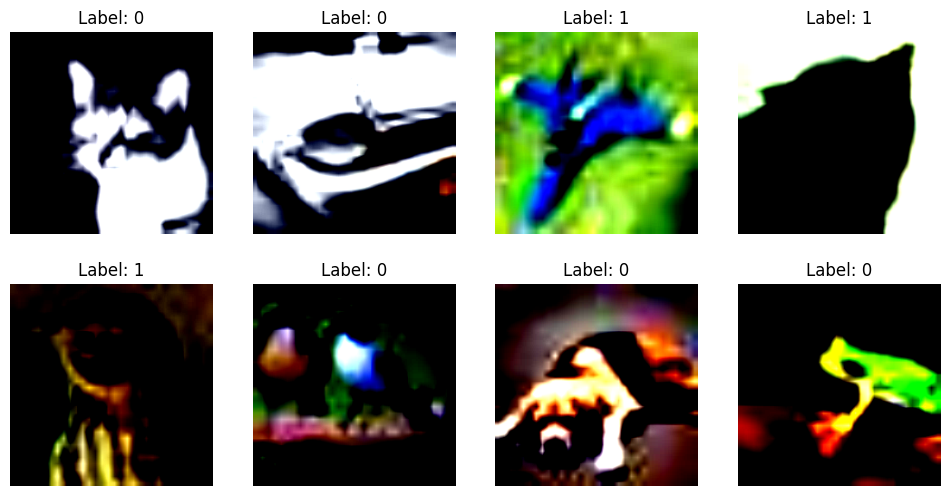

In [16]:
# get a batch of images and labels from the train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

## Preview Validation Data 20% 

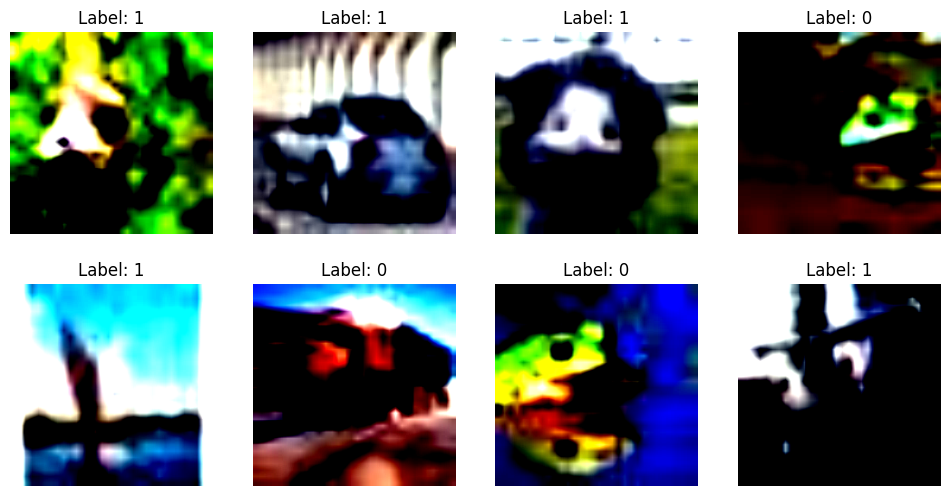

In [17]:
data_iter = iter(val_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

## Preview Testing Data (20,000 Images)

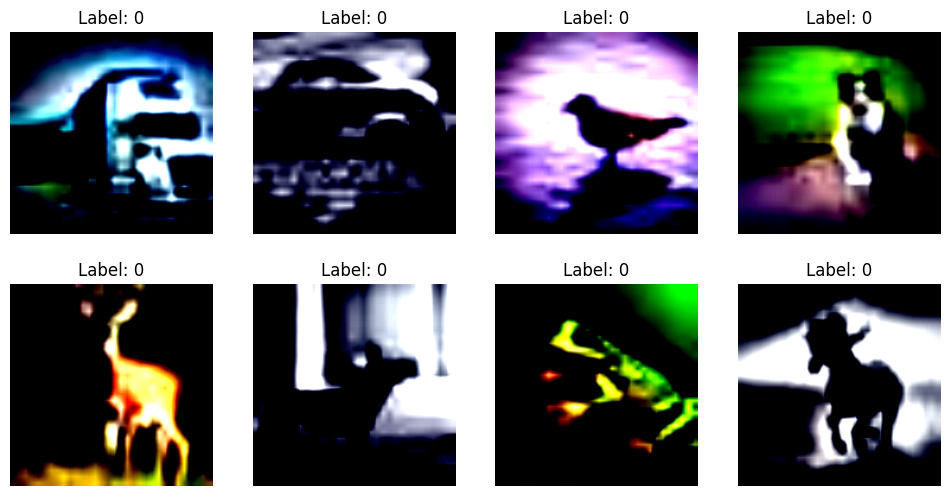

In [18]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

# EfficientNet-B0 Model

## Load Model

In [19]:
#Load pretrained EfficientNet-B0 model
efficientnet_model = models.efficientnet_b0(pretrained=True)

#Call for GPU (if available) for faster training, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Freeze feature extractions from input data
for param in efficientnet_model.features.parameters():
    param.requires_grad = False #Preserve the pre-trained knowledge (Dont update weights during training)

#Define the number of classes (2)
efficientnet_model.classifier[1] = nn.Linear(efficientnet_model.classifier[1].in_features, 2)
efficientnet_model = efficientnet_model.to(device) # Run model on GPU or CPU

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


## Training Model with TRAIN & VALIDATION 

In [20]:
#Load loss function and optimizer
criterion = nn.CrossEntropyLoss() #Inform model how wrong it is and to help it improve
optimizer = optim.SGD(efficientnet_model.parameters(), lr=0.001) #Improves weights based on error (backpropagation)

#Begin Training 
epochs = 5
for epoch in range(epochs):
    efficientnet_model.train()
    training_loss = 0.0
    train_correct = 0
    train_total = 0
    
    print("------------------------------")
    print("Epoch: " + str(epoch + 1))

    #Train model with TRAIN dataset of 80%
    for images, labels in train_loader: # Load training dataset
        images, labels = images.to(device), labels.to(device) #Place into GPU or CPU

        #Reset gradient of optimizer
        optimizer.zero_grad()

        #Inset training images into the model to obtain predictions
        outputs = efficientnet_model(images)
        
        #Calculate loss of the model's predictions through CrossEntropyLoss
        loss = criterion(outputs, labels)

        #Compute the gradient
        loss.backward()
        
        #Improve weight based on error through SGD optimizer
        optimizer.step()

        # Metrics: 
        training_loss += loss.item() #Loss of current epoch
        _, predicted = outputs.max(1) #Obtain predicted class label from highest probability
        train_correct += predicted.eq(labels).sum().item() #Number of correct predictions
        train_total += labels.size(0) #Number of samples processed

    #TRAIN: Average Loss and Accuracy per epoch
    train_loss = training_loss / len(train_loader) #Average loss per epoch
    train_acc = 100 * train_correct / train_total #Accuracy per epoch
    
    #Print 
    print(f"TRAIN Dataset: Avg. Loss: {train_loss:.4f}, Avg. Accuracy: {train_acc:.2f}%")

    #Train model with VALIDATION dataset of 20%
    efficientnet_model.eval()
    validation_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): #Do not calculate gradients when updating the weights
        for images, labels in val_loader: #Load validation images
            images, labels = images.to(device), labels.to(device) #Place into GPU or CPU
    
            #Inset validation images into the model to obtain predictions
            outputs = efficientnet_model(images)
            
            #Calculate loss of the model's predictions through CrossEntropyLoss
            loss = criterion(outputs, labels)
    
            # Metrics: 
            validation_loss += loss.item() #Loss of current epoch
            _, predicted = outputs.max(1) #Obtain predicted class label from highest probability
            val_correct += predicted.eq(labels).sum().item() #Number of correct predictions
            val_total += labels.size(0) #Number of samples processed

    #VALIDATION: Average Loss and Accuracy per epoch
    val_loss = validation_loss / len(val_loader) #Average loss per epoch
    val_acc = 100 * val_correct / val_total #Accuracy per epoch
    
    #Print 
    print(f"VALIDATION Dataset: Avg. Loss: {val_loss:.4f}, Avg. Accuracy: {val_acc:.2f}%")

------------------------------
Epoch: 1
TRAIN Dataset: Avg. Loss: 0.4992, Avg. Accuracy: 78.84%
VALIDATION Dataset: Avg. Loss: 0.4017, Avg. Accuracy: 84.53%
------------------------------
Epoch: 2
TRAIN Dataset: Avg. Loss: 0.4059, Avg. Accuracy: 82.91%
VALIDATION Dataset: Avg. Loss: 0.3593, Avg. Accuracy: 85.78%
------------------------------
Epoch: 3
TRAIN Dataset: Avg. Loss: 0.3821, Avg. Accuracy: 83.68%
VALIDATION Dataset: Avg. Loss: 0.3414, Avg. Accuracy: 86.49%
------------------------------
Epoch: 4
TRAIN Dataset: Avg. Loss: 0.3694, Avg. Accuracy: 84.16%
VALIDATION Dataset: Avg. Loss: 0.3295, Avg. Accuracy: 86.92%
------------------------------
Epoch: 5
TRAIN Dataset: Avg. Loss: 0.3617, Avg. Accuracy: 84.51%
VALIDATION Dataset: Avg. Loss: 0.3240, Avg. Accuracy: 87.25%


## Testing Dataset (20,000 images)

In [21]:
efficientnet_model.eval()
test_labels = [] #The correct labels
test_predict = [] #The predicted labels
print("Loading Testing Dataset")
print("------------------------------")
#Load TESTing dataset into model
with torch.no_grad():
    for images, labels in test_loader: #Call test dataset 
        images, labels = images.to(device), labels.to(device) #Load GPU or CPU
        outputs = efficientnet_model(images) #Load test dataset into model

        _, predicted = outputs.max(1) #Obtain predicted class label from highest probability

        test_labels.extend(labels.cpu().numpy()) #Collect correct labels from gpu to cpu and convert pytorch tensor into a numpy array
        test_predict.extend(predicted.cpu().numpy()) #Collect predicted labels from gpu to cpu and convert pytorch tensor into a numpy array
        
print("Testing Dataset Predictions Complete")

Loading Testing Dataset
------------------------------
Testing Dataset Predictions Complete


# Metrics

## Classification Report, AUC Value, Average Precision

In [22]:
# Classification Report
print("Classification Report:")
print(classification_report(test_labels, test_predict))
print("------------------------------")

# AUC value
aucValue = roc_auc_score(test_labels, test_predict)
print("AUC Value: " + str(aucValue))
print("------------------------------")

# Precision and recall
precision, recall, thresholds = precision_recall_curve(test_labels, test_predict)
average_precision = average_precision_score(test_labels, test_predict)
print("Average Precision per Recall: " + str(average_precision))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     10000
           1       0.87      0.87      0.87     10000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000

------------------------------
AUC Value: 0.86925
------------------------------
Average Precision per Recall: 0.8207391684136967


## Display Confusion Matrix

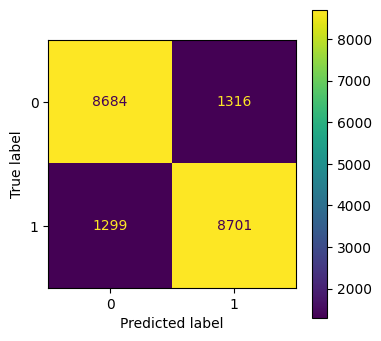

In [23]:
# Confusion matrix
confusionMatrix = confusion_matrix(test_labels, test_predict)

# Display confusion matrix
confusionMatrixPlot = ConfusionMatrixDisplay(confusion_matrix = confusionMatrix)
plt.figure(figsize=(4, 4))
confusionMatrixPlot.plot(ax=plt.gca())
plt.show()

## Display AUC-ROC Curve

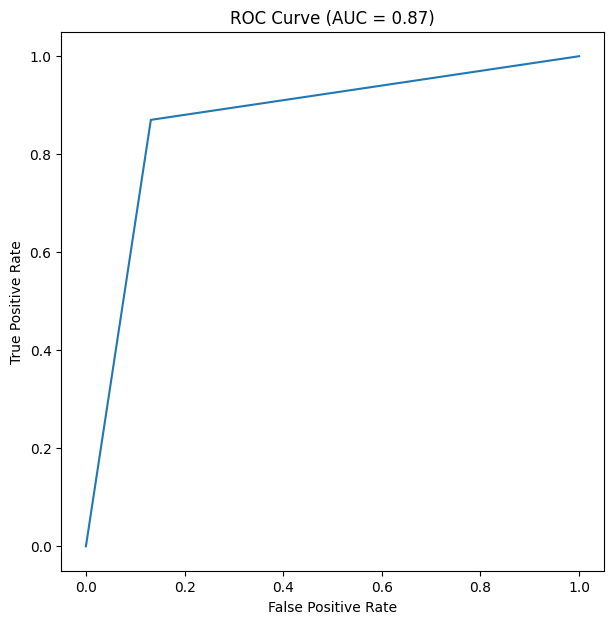

In [24]:
# plot the ROC
fpr, tpr, _ = roc_curve(test_labels, test_predict)
plt.figure(figsize=(7, 7))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_display.plot(ax=plt.gca())
plt.title(f"ROC Curve (AUC = {aucValue:.2f})")
plt.show()

## Display Precision per Recall Curve

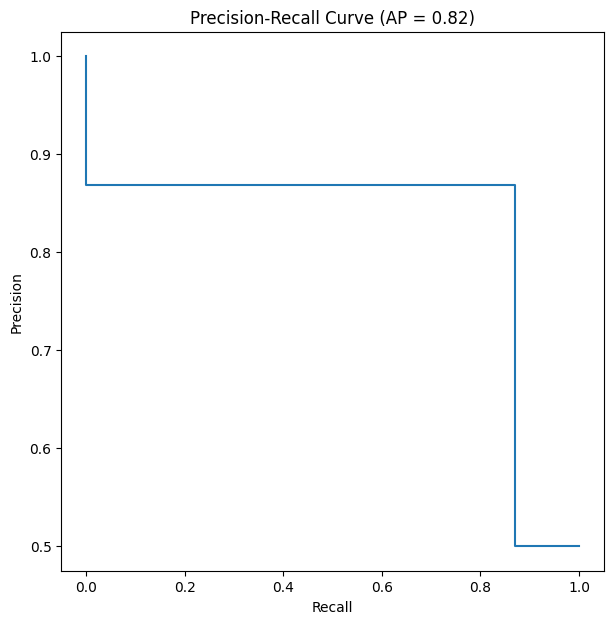

In [25]:
# plot the PRC
fpr, tpr, _ = roc_curve(test_labels, test_predict)
plt.figure(figsize=(7, 7))
PRC_display = PrecisionRecallDisplay(precision= precision, recall=recall)
PRC_display.plot(ax=plt.gca())
plt.title(f"Precision-Recall Curve (AP = {average_precision:.2f})")
plt.show()